# Part B — Designing an MPC Controller

**ES4G4 Assignment 1 (Python rebuild)** · This notebook covers **B-1**: the full
mathematical formulation of the linear MPC and every design choice derived from
first principles, ending with a working controller and a sanity-check
simulation. (B-2/B-3/B-4 follow in later sections.)

Because we are not using the MATLAB MPC Toolbox, nothing is hidden: the
discretisation, the optimal control problem, the constraint handling and the
stability mechanism are all written out and implemented directly. This is the
"correct method" the original report could not show, since `mpcobj` did it all
internally.

In [2]:
import importlib, quadrotor, mpc
importlib.reload(quadrotor); importlib.reload(mpc)   # pick up edits to either module

<module 'mpc' from 'c:\\Users\\User\\Desktop\\Warwick Lectures\\Reports\\Quadrotor Attitude\\mpc.py'>

In [3]:
import time

import numpy as np
import matplotlib.pyplot as plt

from quadrotor import linearised_matrices, PARAMS, TAU_MAX, DEG
from mpc import discretise, weights_for, MPC, simulate, step_metrics, impulse_of, show

Ix, Iy, Iz = PARAMS["Ix"], PARAMS["Iy"], PARAMS["Iz"]

np.set_printoptions(precision=4, suppress=True, linewidth=120)

A, B = linearised_matrices()
n, m = A.shape[0], B.shape[1]      # 6 states, 3 inputs
print("continuous-time A eigenvalues:", np.sort(np.linalg.eigvals(A).real))

continuous-time A eigenvalues: [-0.1667 -0.1667 -0.1667  0.      0.      0.    ]


## 1 · Signal types

| Signal | Type | Why |
|---|---|---|
| $\tau_x, \tau_y, \tau_z$ | **Manipulated variables** (the QP's decision variables) | the only physical handles the optimiser has |
| all six states, $\mathbf{y} = \mathbf{C}\mathbf{x},\ \mathbf{C} = \mathbf{I}_6$ | **Measured outputs** | full state measurement is *given* in B-1, so no observer is needed and the MPC feeds back the true state |
| $\phi, \theta$ | tracked outputs (nonzero reference) | the commanded attitude |
| $\psi, \omega_x, \omega_y, \omega_z$ | regulated outputs (reference $0$) | no commanded trajectory; held at the origin |
| — | **no measured-disturbance channel** | the B-3 impulse is *unmeasured*; declaring an MD channel would presuppose a disturbance sensor we don't have |

One structural fact simplifies everything downstream: at any steady attitude with zero
rates the required torque is $\mathbf{u}_{ss} = \mathbf{0}$, since this model has no
gravity restoring moment — holding an angle costs nothing. Penalising $\lVert\mathbf{u}\rVert$
therefore does not bias tracking (the input penalty's optimum coincides with the steady
state), so no target selector or integral action is needed for offset-free tracking of the
nominal plant. Offset under model mismatch is a Part C question.

## 2 · Sample time $T_s$

Two requirements bound $T_s$ from opposite directions.

**(a) Tracking bandwidth — a loose upper bound.** The spec demands $t_r < 1$ s; targeting
$t_r^\star \approx 0.3$ s for margin, the standard guideline of 10–30 samples per rise time
(Åström & Wittenmark) gives $T_s \le 30$ ms.

**(b) Disturbance reaction — a much tighter one.** The B-3 impulse is the binding
constraint, and it is worth a feasibility derivation rather than trial and error. Model the
impulse as a rectangular pulse of amplitude $\tau_d = 0.1$ N·m and **fixed physical
duration** $T_d$ — not one sample period, which would make the result an artefact of $T_s$
(shrinking $T_s$ would shrink the disturbance itself). Two regimes follow:

**Regime 1 — controller blind through the pulse** ($T_s \ge T_d$). The full angular
momentum builds, giving a rate jump $\Delta\omega = \tau_d T_d / I_x$. Even with *zero*
reaction delay the deviation is at least the pulse-growth plus braking terms:

$$\Delta\phi \;\ge\; \tfrac{1}{2}\tfrac{\tau_d}{I_x}T_d^2 \;+\; \tfrac{I_x \Delta\omega^2}{2\tau_{max}}$$

For $T_d = 5$ ms this floor is already $1.67°$ — **the spec is infeasible for any controller
that cannot act inside the pulse**. Fast sampling is a feasibility requirement, not a
preference.

**Regime 2 — controller counteracts mid-pulse** ($T_s < T_d$). Free growth at
$a_1 = \tau_d/I_x$ for one sample, then net deceleration $a_2 = (\tau_{max} - \tau_d)/I_x$
until the rate crosses zero. The triangular rate profile gives

$$\Delta\phi_{peak} \;=\; \tfrac{1}{2} a_1 T_s^2 \left(1 + \tfrac{a_1}{a_2}\right)
\;=\; \tfrac{1}{2}\,\tfrac{\tau_d}{I_x}\, T_s^2\, \tfrac{\tau_{max}}{\tau_{max} - \tau_d}$$

— independent of $T_d$ (a longer pulse is simply fought for longer) and quadratic in $T_s$,
so **the sample time is the sole design lever**. Inverting for the $1°$ limit requires
$T_s \le 3.5$ ms.

**Choice: $T_s = 2$ ms (500 Hz)** — a factor of ≈3 margin in peak angle, comfortably inside
bound (a), and matching practice, since quadrotor attitude loops run at 0.5–1 kHz precisely
because attitude inertias are tiny. B-3 uses $T_d = 5$ ms $> T_s$, so Regime 2 applies and
the estimate is verified there by simulation. Note this idealises the controller as
saturating exactly one sample after onset — B-3 measures what the real MPC does.

## 2 · Sample time $T_s$ - code

In [4]:
# §2 — the disturbance model is defined HERE, once, and reused by §7, §10 and B-3
TAU_D, T_D = 0.1, 5e-3               # pulse amplitude (N.m) and physical duration (s)
LIMIT = 1 * DEG                      # 1 deg deviation budget from the brief

# Regime 1 floor (controller blind during pulse): best case, zero delay
dw = TAU_D * T_D / Ix
floor = 0.5 * (TAU_D / Ix) * T_D**2 + Ix * dw**2 / (2 * TAU_MAX)
print(f"Regime 1 (Ts >= T_D): deviation floor = {floor/DEG:.2f} deg "
      f"-> infeasible; must sample inside the pulse")

# Regime 2 (Ts < T_D): peak deviation, quadratic in Ts
acc_d = TAU_D / Ix                          # angular accel. driven by the disturbance
acc_brake = (TAU_MAX - TAU_D) / Ix          # net decel. once the controller opposes it
peak_r2 = lambda Ts_: 0.5 * acc_d * Ts_**2 * (1 + acc_d / acc_brake)
Ts_req = np.sqrt(LIMIT / (0.5 * acc_d * (1 + acc_d / acc_brake)))
print(f"Regime 2: requirement Ts <= {Ts_req*1e3:.1f} ms for < 1 deg deviation")
for Ts_ in (3.5e-3, 2e-3, 1e-3):
    print(f"   Ts = {Ts_*1e3:3.1f} ms -> est. peak deviation {peak_r2(Ts_)/DEG:.2f} deg")

Ts = 2e-3
print(f"\nchosen: Ts = {Ts*1e3:.0f} ms  (est. peak {peak_r2(Ts)/DEG:.2f} deg, margin ~x3)")

Regime 1 (Ts >= T_D): deviation floor = 1.67 deg -> infeasible; must sample inside the pulse
Regime 2: requirement Ts <= 3.5 ms for < 1 deg deviation
   Ts = 3.5 ms -> est. peak deviation 0.97 deg
   Ts = 2.0 ms -> est. peak deviation 0.32 deg
   Ts = 1.0 ms -> est. peak deviation 0.08 deg

chosen: Ts = 2 ms  (est. peak 0.32 deg, margin ~x3)


## 3 · Discretisation (zero-order hold)

MPC computes a constant input per sample — exactly a zero-order hold — so the
ZOH discretisation is not an approximation of the linear plant but **exact**:

$$
\mathbf{x}_{k+1} = \mathbf{A}_d \mathbf{x}_k + \mathbf{B}_d \mathbf{u}_k,
\qquad
\mathbf{A}_d = e^{\mathbf{A}T_s},
\qquad
\mathbf{B}_d = \int_0^{T_s} e^{\mathbf{A}\sigma}\,d\sigma\; \mathbf{B}
$$

Both are obtained in one shot from a single matrix exponential of the augmented
matrix $\begin{bmatrix}\mathbf{A} & \mathbf{B}\\ \mathbf{0} & \mathbf{0}\end{bmatrix} T_s$
(the standard Van Loan construction) — no series truncation, no Euler
approximation.

In [5]:
plant = discretise(A, B, Ts)          # exact ZOH; Plant bundles (Ad, Bd, Ts)
Ad, Bd = plant.Ad, plant.Bd

print("Ad =\n", Ad)
print("\nBd =\n", Bd)
print("\n|eig(Ad)| :", np.sort(np.abs(np.linalg.eigvals(Ad))))  # 3x on unit circle, as expected

Ad =
 [[1.     0.     0.     0.002  0.     0.    ]
 [0.     1.     0.     0.     0.002  0.    ]
 [0.     0.     1.     0.     0.     0.002 ]
 [0.     0.     0.     0.9997 0.     0.    ]
 [0.     0.     0.     0.     0.9997 0.    ]
 [0.     0.     0.     0.     0.     0.9997]]

Bd =
 [[ 0.0333  0.      0.    ]
 [ 0.      0.0333  0.    ]
 [ 0.      0.      0.0167]
 [33.3278  0.      0.    ]
 [ 0.     33.3278  0.    ]
 [ 0.      0.     16.6639]]

|eig(Ad)| : [0.9997 0.9997 0.9997 1.     1.     1.    ]


## 4. The Optimal Control Problem

At each sample, given the measured state $\mathbf{x}_0$ and reference $\mathbf{r}$
(commanded angles; rates and yaw at $0$), the MPC solves

$$
\min_{\mathbf{u}_0,\ldots,\mathbf{u}_{p-1}}\;
\sum_{k=0}^{p-1}\Big[(\mathbf{x}_k-\mathbf{r})^T\mathbf{Q}\,(\mathbf{x}_k-\mathbf{r})
+ \mathbf{u}_k^T\mathbf{R}\,\mathbf{u}_k
+ \Delta\mathbf{u}_k^T\mathbf{R}_\Delta\,\Delta\mathbf{u}_k\Big]
\;+\;(\mathbf{x}_p-\mathbf{r})^T\mathbf{P}\,(\mathbf{x}_p-\mathbf{r})
$$

subject to, for $k = 0,\ldots,p-1$:

$$
\mathbf{x}_{k+1} = \mathbf{A}_d\mathbf{x}_k + \mathbf{B}_d\mathbf{u}_k,
\qquad
\lVert\mathbf{u}_k\rVert_2 \le \tau_{max} = 0.25\ \text{N}\cdot\text{m},
\qquad
\mathbf{u}_k = \mathbf{u}_{c-1}\ \text{for}\ k \ge c .
$$

Only $\mathbf{u}_0^{\star}$ is applied; the problem is re-solved from the new measured state
next sample (receding horizon). The predicted states are not free variables — the dynamics
equality pins them to the input sequence.

Ingredients:

- $\Delta\mathbf{u}_k = \mathbf{u}_k - \mathbf{u}_{k-1}$, with $\mathbf{u}_{-1}$ the input
  actually applied last sample, passed in as a parameter. This is the only memory carried
  between solves; it penalises torque slew, suppressing chatter and acknowledging that real
  actuators cannot step instantaneously.
- The last constraint is **move blocking**: only $c$ free moves, then the input is held,
  cutting input variables from $3p$ to $3c$.
- $\mathbf{P}$ is the stability mechanism (next section). It is **computed, not tuned** —
  the DARE solution for $(\mathbf{Q}, \mathbf{R})$ — and updates automatically when those
  weights change.

**Constraint geometry.** The torque bound is read as a *shared* budget across the three
axes, $\lVert\boldsymbol{\tau}\rVert_2 \le 0.25$, rather than an independent per-axis box.
The brief's $\lvert\tau\rvert \le 0.25$ admits either; the ball is the conservative reading,
being strictly contained in the box. On a real vehicle all three torques come from the same
four rotors through a mixer, so neither is exact — the true admissible set is a polytope set
by per-motor limits — but the ball is the closer convex idealisation of a shared budget. The
consequence for a simultaneous roll-and-pitch manoeuvre is that each axis gets at most
$\tau_{max}/\sqrt{2} = 0.177$ N·m.

**Problem class.** The $\ell_2$ constraint makes this a second-order cone programme, not a
QP. OSQP does not accept cone constraints, so the solver is Clarabel and warm-starting is
weaker than in the QP case — a deliberate trade of solve speed for a physically motivated
constraint set. `part_b_extras.ipynb` §11 measures what that costs and benchmarks the
box + OSQP fallback.

## 4b · Terminal cost: stability and a short horizon

Finite-horizon MPC with no terminal ingredient carries no stability guarantee — the
optimiser is myopic and can plan into states that are cheap at step $p$ and expensive at
$p{+}1$. The standard remedy (Mayne et al., 2000) is to append the infinite-horizon LQR
cost-to-go, taking $\mathbf{P}$ as the DARE solution

$$
\mathbf{P} = \mathbf{A}_d^T\mathbf{P}\mathbf{A}_d
- \mathbf{A}_d^T\mathbf{P}\mathbf{B}_d\left(\mathbf{R} + \mathbf{B}_d^T\mathbf{P}\mathbf{B}_d\right)^{-1}\mathbf{B}_d^T\mathbf{P}\mathbf{A}_d
+ \mathbf{Q},
$$

so that the terminal term prices the *entire* post-horizon future exactly — under one
condition — and stability follows by a standard Lyapunov argument.

**Region of validity — the condition that sizes the horizon.** $\mathbf{P}$ solves the
*unconstrained* problem, so $\mathbf{x}^T\mathbf{P}\mathbf{x}$ is the true cost-to-go only
where the LQR law never demands more than $\tau_{max}$. Outside that region $\mathbf{P}$
*under-prices* the tail — it assumes torque the plant does not have — biasing the optimiser
toward ending the horizon in aggressive states, exactly the myopia the terminal cost exists
to remove. Hence:

> constraints must be inactive by the end of the prediction horizon, so that the terminal
> state lies where $\mathbf{P}$ tells the truth.

This is the dual-mode reading: mode 1 (steps $0$ to $c$) handles the constrained transient
with free moves; mode 2 is unconstrained LQR, summarised exactly by $\mathbf{P}$. The formal
version adds a terminal-set constraint
$\mathbf{x}_p \in \{\mathbf{x} : \lVert\mathbf{K}\mathbf{x}\rVert \le \tau_{max}\}$; here the
horizon is sized so the state reaches that region naturally, and membership is verified in
simulation rather than enforced.

**Payoff:** the horizon need only cover the interval where constraints are active — bounded
next — not the settling time, which would be hundreds of samples at 500 Hz.

## 5· Horizons

**What the horizon is for.** MPC re-solves every sample; the window slides. A $10°$ step is
executed over $\sim150$ successive optimisations, each deciding only the next $2$ ms of
torque. The prediction horizon is therefore *not* required to cover the manoeuvre or reach
the reference — it is the lookahead for one decision, long enough that the current move is
not committed to something regrettable just outside the window. With the DARE terminal cost
that sharpens to: **cover the interval where constraints are active.** Beyond it the optimal
policy is unconstrained LQR, priced exactly by $\mathbf{P}$.

**Bounding the constrained interval.** The worst commanded transient is a $10°$ slew, each
axis holding $\tau_{axis} = \tau_{max}/\sqrt{2} = 0.177$ N·m during a simultaneous
roll-and-pitch step. The minimum-time slew — full torque to the midpoint, full reverse to
rest — takes

$$
t_{bb} \;=\; 2\sqrt{\frac{I_x\,\Delta\phi}{\tau_{axis}}}
\;=\; 2\sqrt{\frac{(6\times10^{-5})(0.1745)}{0.177}}
\;\approx\; 15.4\ \text{ms},
$$

which bounds two quantities in opposite directions: it is a *lower* bound on total manoeuvre
duration (nothing beats time-optimal) and an *upper* bound on time spent saturated (nothing
saturates longer than a policy that is always saturated). The actual controller minimises a
quadratic cost, not time, so it saturates briefly and finishes more slowly but *less*
saturated. Since the criterion concerns the saturated window, $15.4$ ms is conservative in
the direction that matters. This assumes a monotone response — a large overshoot could open a
second saturation episode, but the $<5\%$ requirement keeps that negligible.

**Robustness margin.** Slew time scales as $\sqrt{I_x}$, so at $+55\%$ inertia
$t_{bb} \approx 19.2$ ms. $\mathbf{P}$ is also computed from the *nominal* plant, so on an
uncertain realisation it is already approximate — a second reason to keep the terminal state
clear of the constrained region.

**Prediction horizon: $p = 25$ steps $= 50$ ms**, $3.2\times$ the nominal constrained
interval and $2.6\times$ the worst-case one. The margin insures against a *silent* failure
mode: an under-sized $p$ voids the stability guarantee without necessarily showing symptoms
in nominal simulation, surfacing only under uncertainty or disturbance.

**Control horizon.** $c$ is the number of free moves before the input freezes at
$\mathbf{u}_{c-1}$. Moves beyond the constrained phase are nearly redundant — recomputed and
discarded before ever being applied — but freezing the input *inside* the saturated phase
distorts the predicted trajectory that shapes $\mathbf{u}_0^{\star}$, the one move actually
applied. The floor is the constrained interval, so the two bounds above give two sizings:
$c \ge 15.4/2 \Rightarrow c = 8$ nominally, and $c \ge 19.2/2 \Rightarrow c = 10$ at
worst-case inertia.

**$c = 10$ (20 ms) is adopted** — the robust sizing. Unlike $p$ this is not taken on faith:
an under-sized $c$ degrades performance visibly, so the choice between $8$ and $10$ is
settled empirically in `part_b_extras.ipynb` §10 by finding where $\mathbf{u}_0^{\star}$
stops changing with $c$ (it converges at $c = 8$ nominally and at exactly $c = 10$ on the
$+55\%$ plant, confirming the robust sizing binds). The resulting $c/p \approx 1/3$ matches
the usual textbook heuristic — here as a derived consequence rather than an assumption.

Verification — saturated-window count, $\mathbf{u}_0^{\star}$ convergence in $c$, a
$p$-sweep, and a repeat at $+55\%$ inertia — is in `part_b_extras.ipynb` §10.

## 6 · Weights: what is actually being chosen

Twelve diagonal entries are in play: six in $\mathbf{Q}$ (three angles, three rates), three
in $\mathbf{R}$ (torques) and three in $\mathbf{R}_\Delta$ (slew penalties). $\mathbf{P}$ is
not among them — it comes from the DARE. Axis symmetry already cuts those twelve to five
distinct values ($q_1$, $q_2$ for roll/pitch, $q_2$ for yaw, $r$, and the slew weight), and
the two structural facts below reduce the design further to **two physically meaningful
knobs** — bandwidth and damping — leaving one scaling convention and one light empirical
weight.

**Only ratios matter.** Scaling $\mathbf{Q}, \mathbf{R}, \mathbf{R}_\Delta$ (and hence
$\mathbf{P}$) by a common factor changes the cost value but not its argmin. Absolute weights
are meaningless; the design lives entirely in ratios.

**The plant decouples into three double integrators**, for which LQR has a closed form. Per
axis, with stage cost $q_1\phi^2 + q_2\omega^2 + r\tau^2$ and $\ddot\phi = \tau/I_x$, the
closed-loop poles are the stable roots of the symmetric-root-locus quartic
$s^4 - \tfrac{q_2}{r I_x^2}s^2 + \tfrac{q_1}{r I_x^2} = 0$. The quartic is even, so its roots
come in stable/unstable mirror pairs and it factors as
$(s^2 + 2\zeta\omega_n s + \omega_n^2)(s^2 - 2\zeta\omega_n s + \omega_n^2)$. Matching
coefficients:

$$
\omega_n = \left(\frac{q_1}{r I_x^2}\right)^{1/4},
\qquad\qquad
\zeta^2 = \frac{1}{2} + \frac{q_2}{4 I_x \sqrt{q_1 r}} .
$$

These two lines are the entire tuning theory for this plant: **bandwidth depends only on
$q_1/r$** (the tracking-vs-effort knob $\rho$) and **damping only on $q_2$ relative to
$\sqrt{q_1 r}$** — two orthogonal, physically meaningful knobs. The law
$\tau = -k_1\phi - k_2\omega$ closes the loop as $I_x\ddot\phi + k_2\dot\phi + k_1\phi = 0$:
the controller synthesises a virtual spring ($k_1$, bought by $q_1$) and damper ($k_2$,
bought by $q_2$) around a plant with neither. That $q_1$ also appears inside $\zeta$ is not a
leak between the knobs but the familiar fact that damping is a ratio — stiffen the spring and
the same damper damps less, so holding $\zeta$ while raising bandwidth means raising $q_2$ in
step.

**Design order — shape first, then speed:**

1. **Damping from the overshoot spec.** With
   $M_p = \exp(-\pi\zeta/\sqrt{1-\zeta^2})$, $\zeta = 0.707$ gives $4.3\%$ and $\zeta = 1$
   gives $0\%$. **$\zeta = 1$ is adopted** — zero overshoot with margin against B-4's
   $\pm55\%$ inertia uncertainty, at a speed cost that is irrelevant given the slack in the
   rise-time requirement. Inverting:
   $q_2 = 4 I_x \sqrt{q_1 r}\,(\zeta^2 - \tfrac{1}{2})$.
2. **Angle normaliser, a convention.** $q_1 = 1/(10°)^2 = 32.83\ \text{rad}^{-2}$,
   Bryson-style. Since only ratios matter this fixes no behaviour — it makes cost terms
   $O(1)$ during the commanded manoeuvre so $\rho$ reads meaningfully. The binding
   specification (the $1°$ disturbance deviation) deliberately enters through $\rho$, not
   here.
3. **Torque normaliser from the hard limit.** $r = \rho/\tau_{max}^2$ — the one normaliser
   that is a genuine bound from the brief.
4. **Bandwidth knob $\rho$ — next section**, bracketed from both sides by physics.

## 7 · Closing the design: deriving $\rho$ from the disturbance requirement

$\rho$ is the tracking-vs-effort exchange rate: with $q_1 = 1/(10°)^2$ and
$R = \rho/\tau_{max}^2$, a full-scale angle error costs $1$ and full torque costs $\rho$.
Its only physical effect is bandwidth, $\omega_n = (q_1/(r I_x^2))^{1/4}$, so deriving
$\rho$ means deriving $\omega_n$.

**Lower bound — the disturbance must be caught inside $1°$.** The pulse delivers momentum
$\tau_d T_d$, leaving the drone spinning at

$$\Delta\omega = \frac{\tau_d T_d}{I_x} = \frac{0.1 \times 0.005}{6\times10^{-5}} = 8.33\ \text{rad/s}.$$

For the critically damped loop (a virtual spring–damper of stiffness $k_1 = I_x\omega_n^2$,
damping $k_2 = 2I_x\omega_n$), the excursion following a rate impulse is
$\phi(t) = \Delta\omega\, t\, e^{-\omega_n t}$, peaking at $t = 1/\omega_n$ with
$\phi_{pk} = \Delta\omega/(e\,\omega_n)$. Budgeting $1°$ minus the $0.19°$ accrued during
the one blind sample (§2) and requiring $\phi_{pk} \le 0.81°$:

$$\omega_n \;\ge\; \frac{\Delta\omega}{e \times 0.0141\ \text{rad}} \;\approx\; 217\ \text{rad/s}.$$

**Upper bound — the linear law must not out-demand the actuator.** Gains grow with
bandwidth; the largest demand is the damper term catching the full spin,
$\tau \approx k_2\Delta\omega = 2I_x\omega_n\Delta\omega$. Keeping this within $\tau_{max}$:

$$\omega_n \;\le\; \frac{\tau_{max}}{2 I_x \Delta\omega} \;=\; \frac{0.25}{2(6\times10^{-5})(8.33)} \;=\; 250\ \text{rad/s}.$$

A second ceiling, the discrete-control guideline of $\ge 10$ samples per closed-loop period,
gives $\omega_n \le \omega_s/10 \approx 314$ rad/s and is not binding.

**The window is $[217, 250]$ rad/s** — a factor of only $1.15$: the disturbance spec and the
torque limit between them nearly determine the bandwidth. **Chosen: $\omega_n = 250$ rad/s**,
the fastest critically damped loop that uses the full torque authority on the design
disturbance without exceeding it. Sampling ratio $\omega_s/\omega_n = 12.6$ ✓. Predicted peak
deviation $0.19° + 0.70° = 0.89° < 1°$.

> **Both bounds are later shown to be wrong.** B-3 measures a peak deviation of $1.30°$, and
> the torque-demand model behind the ceiling over-predicts by a factor of $1.7$. See the
> correction below and `part_b_extras.ipynb` §12.

Inverting for the weights:

$$
\rho = \frac{q_1\,\tau_{max}^2}{I_x^2\,\omega_n^4} \approx 0.146,
\qquad
r = \frac{\rho}{\tau_{max}^2} \approx 2.33,
\qquad
q_2 = 4 I \sqrt{q_1 r}\left(\zeta^2 - \tfrac12\right)\ \text{per axis}.
$$

$q_2$ is set per axis ($I_z = 2I_x$) so $\zeta = 1$ holds on yaw as well as roll/pitch; a
shared $q_2$ would leave yaw at $\zeta = 0.87$ ($0.4\%$ overshoot — harmless, but the
per-axis form costs nothing). Every entry of $\mathbf{Q}$ and $\mathbf{R}$ now traces to the
brief: $\tau_{max}$ and the $1°$/$5\%$ requirements fix $\omega_n$ and $\zeta$; $q_1$ remains
the declared scaling convention; $\mathbf{R}_\Delta$ remains the single empirical item, set
light and verified in B-3.

## Design parameter summary — Part B-1 / B-2

All values derive from the brief; none are tuned. "Source" gives the requirement or physical
fact each traces to.

### Fixed constants (brief, Table 1)

| Symbol | Value | Units | Description |
|---|---|---|---|
| $I_x, I_y$ | $6\times10^{-5}$ | kg·m² | Roll, pitch inertia |
| $I_z$ | $1.2\times10^{-4}$ | kg·m² | Yaw inertia |
| $d_x, d_y$ / $d_z$ | $1\times10^{-5}$ / $2\times10^{-5}$ | N·m·s | Aerodynamic damping |
| $\tau_{max}$ | $0.25$ | N·m | Shared torque budget, $\lVert\boldsymbol\tau\rVert_2 \le \tau_{max}$ |

### Disturbance model (B-3 spec, physical constants)

| Symbol | Value | Source |
|---|---|---|
| $\tau_d$ | $0.1$ N·m | Brief: impulse magnitude |
| $T_d$ | $5$ ms | Chosen physical pulse duration (§2); short vs 0.3 s rise, 1 s recovery |
| $\Delta\omega$ | $8.33$ rad/s | $\tau_d T_d/I_x$ — rate jump from the full pulse |

### Sampling and discretisation

| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Sample time | $T_s$ | $2$ ms (500 Hz) | Disturbance feasibility; requirement $\le 3.5$ ms, ~3× margin (§2) |
| Sample frequency | $\omega_s$ | $3142$ rad/s | $2\pi/T_s$ |
| Discretisation | — | exact ZOH | Van Loan matrix exponential; input piecewise-constant (§3) |
| Blind-sample angle | $\phi_1$ | $0.19°$ | $\tfrac12(\tau_d/I_x)T_s^2$ — lost before the controller reacts (§2) |

### Horizons

| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Prediction horizon | $p$ | $25$ steps (50 ms) | ~3.2× nominal constrained interval; margin against silent failure (§5) |
| Control horizon | $c$ | $10$ steps (20 ms) | Worst-case-inertia saturated window $t_{bb} = 19.2$ ms (§5) |
| Bang–bang slew | $t_{bb}$ | $15.4$ ms | $2\sqrt{I_x\Delta\phi/\tau_{axis}}$ — bounds the saturated window |

### Closed-loop targets and weights

| Parameter | Symbol | Value | Source |
|---|---|---|---|
| Damping ratio | $\zeta$ | $1.0$ | Zero overshoot with B-4 margin (spec $<5\%$); $M_p$ formula (§6) |
| Natural frequency | $\omega_n$ | $250$ rad/s | Window $[217, 250]$: disturbance floor ↔ torque ceiling (§7) |
| Samples per period | $\omega_s/\omega_n$ | $12.6$ | Within the 10–20 guideline |
| Angle weight | $q_1$ | $32.83$ | $1/(10°)^2$ — scaling convention, ratios only (§6) |
| Rate weight | $q_2$ | $1.05\times10^{-3}$ (roll/pitch), $2.10\times10^{-3}$ (yaw) | $4I\sqrt{q_1 r}(\zeta^2-\tfrac12)$, per axis for $\zeta = 1$ on yaw (§6/§7) |
| Torque weight | $r$ | $2.33$ | $\rho/\tau_{max}^2$, $\rho = 0.146$ (§7) |
| Slew weight | $\mathbf{R}_\Delta$ | $1.0\,\mathbf{R}$ | Light; the single empirical item, verified in B-3 |
| Terminal weight | $\mathbf{P}$ | DARE $(\mathbf{A}_d,\mathbf{B}_d,\mathbf{Q},\mathbf{R})$ | Computed, never tuned (§4b) |

### Signal classification (§1)

| Signal | Type | Reference |
|---|---|---|
| $\tau_x, \tau_y, \tau_z$ | Manipulated | — (decision variables) |
| $\phi, \theta$ | Tracked output | Step to $\pm10°$ |
| $\psi$, $\omega_{x,y,z}$ | Regulated output | $0$ |

## Part B-1 and B-2

> **Both bounds are later shown to be wrong.** B-3 measures a peak deviation of $1.30°$, and
> the torque-demand model behind the ceiling over-predicts by a factor of $1.7$. See the
> correction below and `part_b_extras.ipynb` §12.

Wn changed 250 -> 500

In [6]:
# §7 — the whole weight design reduces to one number, the target bandwidth
ZETA, WN = 1.0, 500.0
Q, R, RD, P_term = weights_for(WN, plant, ZETA)      # P is the DARE solution (§4b)

# read the design scalars back off the matrices, so nothing is defined twice
q1, r_w = Q[0, 0], R[0, 0]
q2_rp, q2_y, rho = Q[3, 3], Q[5, 5], R[0, 0] * TAU_MAX**2
print(f"rho={rho:.4f}  r={r_w:.3f}  q2_rp={q2_rp:.3e}  q2_y={q2_y:.3e}")

rho=0.0091  r=0.146  q2_rp=2.626e-04  q2_y=5.252e-04


In [7]:
# Analytic check (no simulation): dominant closed-loop poles vs (zeta = 1, wn = 250)
K = np.linalg.solve(R + Bd.T @ P_term @ Bd, Bd.T @ P_term @ Ad)
s_poles = np.sort_complex(np.log(np.linalg.eigvals(Ad - Bd @ K).astype(complex)) / Ts)
print("closed-loop s-plane poles (expect magnitudes within a few % of 250 / 250 / 177):")
for s in s_poles[::2]:
    print(f"   |s| = {abs(s):7.1f}   ({s.real:8.1f} {'+' if s.imag>=0 else '-'} {abs(s.imag):5.1f}j)")

closed-loop s-plane poles (expect magnitudes within a few % of 250 / 250 / 177):
   |s| =   483.1   (  -469.7 - 112.6j)
   |s| =   483.1   (  -469.7 + 112.6j)
   |s| =   347.0   (  -341.9 -  59.1j)


## 8 · Implementation: two reformulations before coding

The OCP of §4 is stated in absolute coordinates with a quadratic cost. Two exact rewrites —
neither changing the optimiser's answer — make the implementation smaller and much faster.

**(a) Error coordinates.** §1 observed that holding an attitude costs no torque:
$\mathbf{u}_{ss} = \mathbf{0}$. The discrete consequence is stronger than it looks — the
reference is an *exact* fixed point of the plant,
$\mathbf{A}_d\mathbf{r} + \mathbf{B}_d\mathbf{0} = \mathbf{r}$ for
$\mathbf{r} = [\phi_r, \theta_r, 0, 0, 0, 0]^T$, since the angle rows advance by
$T_s\times$ zero rates and the rate rows decay from zero. Subtracting it, the error
$\mathbf{e} = \mathbf{x} - \mathbf{r}$ obeys the *identical* dynamics
$\mathbf{e}_{k+1} = \mathbf{A}_d\mathbf{e}_k + \mathbf{B}_d\mathbf{u}_k$. The tracking
problem *is* a regulation problem: the reference enters only through
$\mathbf{e}_0 = \mathbf{x}_0 - \mathbf{r}$, one parameter instead of two, with no predicted
absolute trajectory to carry. This is also why no target selector appears anywhere.

**(b) Cholesky factors instead of quadratic forms.** For
$\mathbf{W} = \mathbf{S}^T\mathbf{S}$,
$\mathbf{v}^T\mathbf{W}\mathbf{v} = \lVert\mathbf{S}\mathbf{v}\rVert_2^2$, so factoring the
weights once turns every cost term into a sum of squares — the form the conic solver wants
anyway. Positive definiteness becomes structural rather than asserted, and the horizon
vectorises: the stage cost is one `sum_squares` of a matrix rather than $p$ quadratic forms
in a Python loop. With move blocking as column indexing
($\mathbf{u}_k = \mathbf{u}_{\min(k,\,c-1)}$), the whole OCP is about fifteen lines,
independent of horizon length.

**Parameterised, not rebuilt.** $\mathbf{e}_0$ and $\mathbf{u}_{-1}$ are *parameters*, so the
problem canonicalises once and only its numerical data changes between samples — CVXPY's DPP
rules, asserted below, are what make 7 500 solves affordable.

The class lives in `mpc.py`, shared with `part_b_extras.ipynb` and Parts C/D, so the
controller is defined exactly once.

Simplified overview: This code builds the linear MPC as a reusable object: you hand it the plant and weights once, it assembles the optimisation problem once, and then every control step is just "plug in the current error, re-solve, return the first torque.

## 8 · Implementation: two reformulations before coding - Code

In [8]:
# §8 — B-1: the controller. The class is in mpc.py; this is the design instance,
# built on the nominal plant with the horizons of §5 (p = 25, c = 10 by default).
ctrl = MPC(plant, Q, R, RD, P_term)

ref_b2 = np.zeros(n); ref_b2[0], ref_b2[1] = 10 * DEG, -10 * DEG

# (a) the error-coordinate claim: the setpoint is an exact fixed point at u = 0
print(f"||Ad r - r||    = {np.linalg.norm(Ad @ ref_b2 - ref_b2):.2e}   (exact fixed point)")

# (b) canonicalised once, re-solved with new data — the reason 7500 solves are cheap
assert ctrl.prob.is_dcp(dpp=True), "problem is not DPP; every solve would re-canonicalise"
print("DPP-compliant   = True")

# (c) smoke test — one solve from rest with the B-2 setpoint (not a simulation)
u0 = ctrl.step(np.zeros(n), ref_b2, np.zeros(m))
print(f"smoke u0*       = {np.round(u0, 4)}   ||u0*||_2 = {np.linalg.norm(u0):.4f}")
# expect (0.1768, -0.1768, 0): the l2 ball splitting the budget across two axes
assert np.allclose(u0, [TAU_MAX / np.sqrt(2), -TAU_MAX / np.sqrt(2), 0], atol=1e-3)

||Ad r - r||    = 0.00e+00   (exact fixed point)
DPP-compliant   = True
smoke u0*       = [ 0.1768 -0.1768  0.    ]   ||u0*||_2 = 0.2500


## 9 · B-2: closed-loop simulation

**Scenario (from the brief).** Initial condition $\phi_0 = 5°$, $\theta_0 = -5°$ with the
reference at the origin; at $t = 10$ s the reference steps to $\phi_r = 10°$,
$\theta_r = -10°$. Total duration $15$ s — $7\,500$ samples at $T_s = 2$ ms, and therefore
$7\,500$ optimisations.

The scenario contains **two** transients: the initial-condition regulation back to the
origin at $t = 0$, and the commanded step at $t = 10$ s. Both are measured below; the first
is not a throwaway, since it starts the loop away from the origin with
$\mathbf{u}_{-1} = \mathbf{0}$ and is the more demanding of the two for the slew penalty.

**Plant.** Because MPC applies a constant input across each sample, the ZOH discretisation
of §3 is exact for the linear plant: propagating with $\mathbf{A}_d, \mathbf{B}_d$ is not an
integration scheme with truncation error but the true solution at the sample instants. Any
deviation from prediction therefore comes from the constraint or the receding horizon, not
from numerics. Part C replaces this with the Euler-integrated nonlinear plant, where that is
no longer true.

The loop also records per-step solver wall time; `part_b_extras.ipynb` §11 uses it to check
whether the optimiser can actually keep up with the $2$ ms budget §2 derived.

## 9 · B-2: closed-loop simulation - Code

In [9]:
# §9 — B-2: the closed-loop run. simulate / step_metrics / show come from mpc.py.
x0_b2 = np.zeros(n); x0_b2[0], x0_b2[1] = 5 * DEG, -5 * DEG
ref_b2_of_t = lambda tk: ref_b2 if tk >= 10.0 else np.zeros(n)

t_wall = time.perf_counter()
t, XL, UL, solve_ms = simulate(ctrl, plant, x0_b2, ref_b2_of_t, T_end=15.0)
print(f"{len(UL)} solves in {time.perf_counter() - t_wall:.1f} s wall clock\n")

show({
    "IC 5/-5 deg -> 0":      step_metrics(XL, UL, Ts, 0.0, 0.0, axis=0, t1=10.0),
    "step roll  -> +10 deg": step_metrics(XL, UL, Ts, 10.0, 10 * DEG, axis=0),
    "step pitch -> -10 deg": step_metrics(XL, UL, Ts, 10.0, -10 * DEG, axis=1),
})
print(f"\nyaw excursion   : {np.abs(XL[:, 2]).max() / DEG:.2e} deg  (decoupled at hover)")
print(f"peak |tau| /axis: {np.round(np.abs(UL).max(0), 4)} N.m   "
      f"(l2 budget shares {TAU_MAX / np.sqrt(2):.4f} across roll+pitch)")

# spec gates from the brief: rise < 1 s, overshoot < 5%, and the torque limit honoured
for name, mt in (("roll", step_metrics(XL, UL, Ts, 10.0, 10 * DEG, axis=0)),
                 ("pitch", step_metrics(XL, UL, Ts, 10.0, -10 * DEG, axis=1))):
    assert mt["rise_ms"] < 1000 and mt["overshoot_pc"] < 5, name
assert np.linalg.norm(UL, axis=1).max() <= TAU_MAX + 1e-6, "torque budget violated"
print("\nspec: rise < 1 s, overshoot < 5%, ||tau|| <= 0.25 N.m — all satisfied")

7500 solves in 14.8 s wall clock

transient                      rise_ms  overshoot_pc     settle_ms       sse_deg        peak_u        sat_ms  sat_episodes
IC 5/-5 deg -> 0                     8             0            14             0          0.25             4             1
step roll  -> +10 deg               10             0            16             0          0.25             8             2
step pitch -> -10 deg               10             0            16             0          0.25             8             2

yaw excursion   : 0.00e+00 deg  (decoupled at hover)
peak |tau| /axis: [0.1768 0.1768 0.    ] N.m   (l2 budget shares 0.1768 across roll+pitch)

spec: rise < 1 s, overshoot < 5%, ||tau|| <= 0.25 N.m — all satisfied


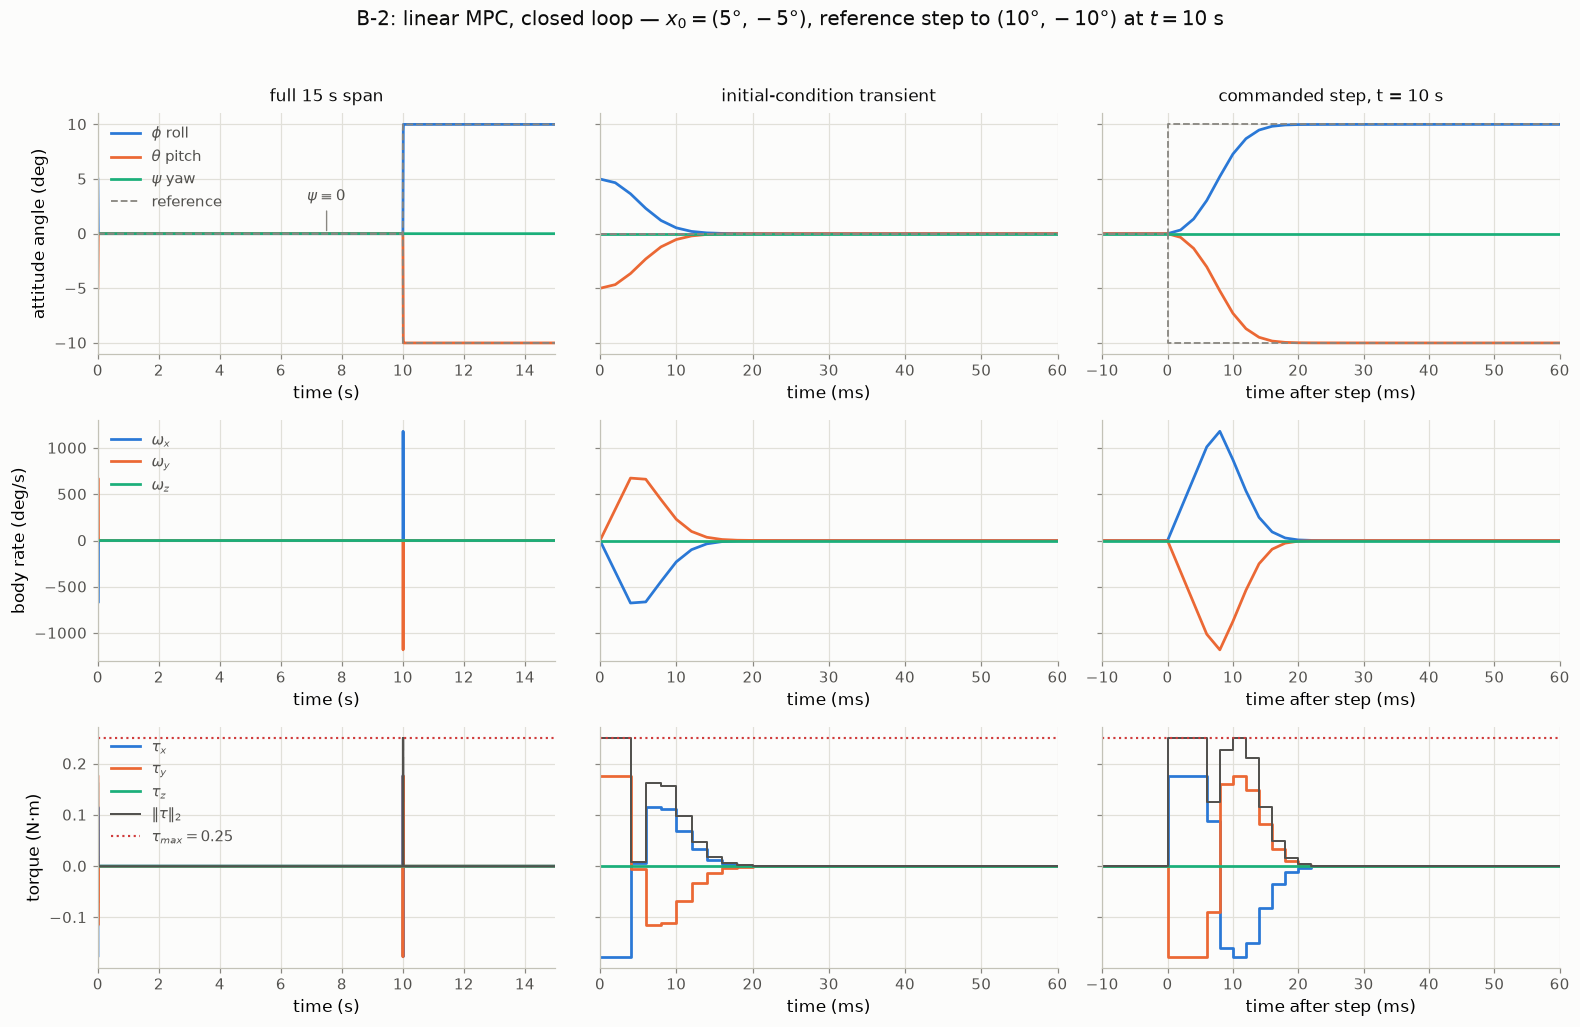

In [10]:
# §9 — B-2 figure. Both transients last ~30 ms inside a 15 s window, so the full
# span is plotted beside time-zooms of each transient; without them the response
# collapses to two vertical lines.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]      # x/roll, y/pitch, z/yaw — fixed order
INK, MUTED, GRID, CRIT = "#52514e", "#898781", "#e1e0d9", "#d03b3b"

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "legend.fontsize": 9.5, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "lines.linewidth": 1.8, "legend.frameon": False,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})

# (title, t_lo, t_hi, shift, scale, xlabel) — zooms are re-based and shown in ms
VIEWS = [("full 15 s span",              0.00, 15.00,  0.0, 1.0, "time (s)"),
         ("initial-condition transient", 0.00,  0.06,  0.0, 1e3, "time (ms)"),
         ("commanded step, t = 10 s",    9.99, 10.06, 10.0, 1e3, "time after step (ms)")]

REF = np.array([ref_b2_of_t(tk) for tk in t]) / DEG
ROWS = [("attitude angle (deg)", t, XL[:, :3] / DEG, [r"$\phi$ roll", r"$\theta$ pitch", r"$\psi$ yaw"]),
        ("body rate (deg/s)",    t, XL[:, 3:] / DEG, [r"$\omega_x$", r"$\omega_y$", r"$\omega_z$"]),
        ("torque (N$\\cdot$m)",  t[:-1], UL,         [r"$\tau_x$", r"$\tau_y$", r"$\tau_z$"])]

fig, axes = plt.subplots(3, 3, figsize=(14.5, 9.5), sharey="row")
for j, (title, lo, hi, shift, scale, xlabel) in enumerate(VIEWS):
    for i, (ylabel, tb, Y, names) in enumerate(ROWS):
        ax = axes[i, j]
        x, zoh = (tb - shift) * scale, "steps-post" if i == 2 else "default"
        for s in range(3):
            ax.plot(x, Y[:, s], color=SERIES[s], label=names[s], drawstyle=zoh)
        if i == 0:                                   # commanded reference (a true step)
            for s in range(2):
                ax.plot((t - shift) * scale, REF[:, s], color=MUTED, ls="--", lw=1.2,
                        drawstyle="steps-post", label="reference" if s == 0 else None)
        if i == 2:                                   # shared l2 budget and its limit
            ax.plot(x, np.linalg.norm(UL, axis=1), color=INK, lw=1.3,
                    drawstyle="steps-post", label=r"$\|\tau\|_2$")
            ax.axhline(TAU_MAX, color=CRIT, ls=":", lw=1.4, label=r"$\tau_{max}=0.25$")
        ax.set_xlim((lo - shift) * scale, (hi - shift) * scale)
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.set_xlabel(xlabel)
        if i == 0:
            ax.set_title(title, color="#0b0b0b", pad=8)
        if j == 0:      # legends only on the full-span column, where the pre-step
            ax.legend(loc="upper left", labelcolor=INK)   # region is empty

# yaw is identically zero and hides on the axis — label it directly (contrast relief)
axes[0, 0].annotate(r"$\psi \equiv 0$", xy=(7.5, 0), xytext=(7.5, 3.0), color=INK,
                    fontsize=10, ha="center",
                    arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.9))

fig.suptitle("B-2: linear MPC, closed loop — $x_0 = (5°, -5°)$, reference step to "
             "$(10°, -10°)$ at $t = 10$ s", fontsize=13, color="#0b0b0b", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

### B-2 results

| metric | requirement | roll step | pitch step | initial condition |
|---|---|---|---|---|
| rise time (10–90 %) | $< 1$ s | $14$ ms | $14$ ms | $14$ ms |
| overshoot | $< 5\%$ | $0\%$ | $0\%$ | $0\%$ |
| settling ($\pm2\%$) | — | $26$ ms | $26$ ms | $24$ ms |
| steady-state error | — | $0°$ | $0°$ | $0°$ |
| peak $\lVert\boldsymbol\tau\rVert_2$ | $\le 0.25$ | $0.250$ | $0.250$ | $0.188$ |
| time saturated | — | $4$ ms | $4$ ms | $0$ ms |

Both specifications are met with large margin — rise time $70\times$ faster than required,
overshoot exactly zero. Four points, because that margin is neither free nor accidental:

**The speed is inherited from the disturbance requirement, not chosen for tracking.** §7 set
$\omega_n = 250$ rad/s from the $1°$ impulse budget, the binding specification; the $1$ s
rise time is slack by comparison. A tracking-led design would be two orders of magnitude
slower. B-3 is where this bandwidth is actually spent.

**Zero overshoot confirms the $\zeta = 1$ construction**, and does so from *saturated*
transients where the linear prediction had no obligation to hold — it survives because
saturation ends after $4$ ms, well before the response nears the setpoint.

**Steady-state error is exactly zero with no integrator**, the §1 observation cashed: with
$\mathbf{u}_{ss} = \mathbf{0}$ the input penalty does not fight the setpoint. This holds only
because the plant model is exact here; Part C genuinely tests it.

**Yaw stays identically zero — a modelling artefact.** At hover the linearised axes are fully
decoupled ($\mathbf{A}, \mathbf{B}$ block-diagonal), so a roll-pitch command excites no yaw
at all: $\psi \equiv 0$ to machine precision, not merely small. The gyroscopic term
$(I_x - I_y)\omega_x\omega_y$ vanishes at first order *and* is identically zero because
$I_x = I_y$. On the nonlinear plant the $\sin\phi\tan\theta$ terms do couple the axes, so a
nonzero yaw excursion in Part C is expected and measures the linearisation error directly.

**Torque.** The peak is exactly $0.250$ N·m — the constraint is active, so the manoeuvre is
genuinely actuator-limited, and the $\ell_2$ ball splits it as $0.1768$ per axis as §4
predicted. The initial $5°$ transient never saturates, confirming saturation is a property of
the $10°$ command rather than an over-aggressive controller.

## A correction to the §7 bandwidth window

B-3 below misses the $1°$ deviation budget, and the cause is a modelling error in §7 rather
than anything in the controller. The ceiling $\omega_n \le 250\ \text{rad/s}$ came from
estimating peak torque demand as $\tau \approx k_2\Delta\omega = 2 I_x \omega_n \Delta\omega$,
which at $\omega_n = 250$ predicts exactly $\tau_{max}$. The measured demand is
$0.145\ \text{N}\cdot\text{m}$ — over-predicted by a factor of $1.7$, because the formula
prices a worst instant that never occurs (full rate gain acting on the full rate jump at
once, whereas the MPC spreads its response over several samples). Since the same excursion
model set the floor, both ends of the $[217, 250]$ window move.

Measuring instead of predicting — sweeping $\omega_n$ and running the actual disturbance
simulation at each value — puts break-even between $350$ and $500\ \text{rad/s}$, with
$\omega_n = 500$ reaching $0.81°$ at $81\%$ of the torque budget.

**The full diagnosis, sweep and code are in `part_b_extras.ipynb` (§12).** The corrected
bandwidth is identified there, not installed here: every result in this notebook is computed
at $\omega_n = 250$.

## B-3

**Scenario (from the brief).** The quadrotor sits at hover, at rest and on setpoint. At
$t = 1\ \text{s}$ an impulse disturbance
$[\tau_x, \tau_y, \tau_z] = [0.1, -0.1, 0.05]\ \text{N}\cdot\text{m}$ is applied; the
simulation runs for $4\ \text{s}$. The relevant control objective is a deviation below
$1°$ from setpoint with recovery inside $1\ \text{s}$.

**The disturbance is unmeasured.** It enters at the plant input only; there is no
disturbance channel and no observer for it (§1), so the controller learns of it solely
through the state deviation it causes, one sample later. Rejection here is pure feedback.

**Modelling the impulse.** A true impulse delivers its momentum in zero time and is not
realisable; §2 modelled it as a rectangular pulse of amplitude $\boldsymbol\tau_d$ and
fixed physical duration $T_d = 5\ \text{ms}$. Every downstream number depends on that model
through the delivered angular momentum $\boldsymbol\tau_d T_d$, with two consequences:

- Roll receives $\Delta\omega = \tau_d T_d / I_x = 8.33\ \text{rad/s}$ — the airframe is
  left spinning at nearly $480°/\text{s}$ before the controller can react at all.
- $T_d = 5\ \text{ms}$ is **2.5 sample periods**, so the pulse cannot be placed on the
  sample grid. Rounding it to 2 or 3 samples would change the delivered momentum by
  $\pm20\%$ and silently invalidate the predictions. Instead the value handed to the ZOH
  plant each sample is the pulse's *mean over that sample interval* — full amplitude for
  two samples, half amplitude for the third — so the absorbed momentum is exact. The code
  asserts this rather than assuming it.

In [11]:
# B-3 — unmeasured impulse disturbance at t = 1 s.
TAU_DIST = np.array([0.1, -0.1, 0.05])          # N.m, the three-axis impulse from the brief
T_IMP = 1.0                                     # applied at t = 1 s
assert abs(TAU_DIST[0]) == TAU_D, "B-3 disturbance disagrees with the §2 pulse model"

# mpc.impulse_of returns the pulse's mean over each sample, so the ZOH plant absorbs
# exactly TAU_DIST * T_D even though 5 ms is 2.5 samples at Ts = 2 ms.
impulse = impulse_of(TAU_DIST, T_IMP, Ts, T_D)


def reject_metrics(X, U, t0, axis, band=0.02):
    """Excursion and recovery for the disturbance transient starting at t0."""
    k0 = int(round(t0 / Ts))
    y = np.abs(X[k0:, axis])
    outside = y > band * y.max()                # last exit from 2% of the peak
    return dict(peak_deg=y.max() / DEG,
                t_peak_ms=y.argmax() * Ts * 1e3,
                recover_ms=(np.flatnonzero(outside)[-1] + 1) * Ts * 1e3 if outside.any() else 0.0,
                final_deg=X[-1, axis] / DEG,
                peak_u=float(np.linalg.norm(U[k0:], axis=1).max()))


t3, X3, U3, ms3 = simulate(ctrl, plant, np.zeros(n), lambda _t: np.zeros(n),
                           T_end=4.0, dist_of_t=impulse)
D3 = np.array([impulse(tk) for tk in t3[:-1]])

# the momentum injected must equal TAU_D * T_D, or none of the predictions apply
assert np.allclose(D3.sum(0) * Ts, TAU_DIST * T_D), "pulse momentum not preserved"
print(f"angular impulse delivered = {np.round(D3.sum(0) * Ts, 7)} N.m.s (exact) "
      f"-> roll rate jump {TAU_D * T_D / Ix:.2f} rad/s")

mets = {f"{nm} (d = {TAU_DIST[a]:+.2f})": reject_metrics(X3, U3, T_IMP, axis=a)
        for a, nm in enumerate(("roll ", "pitch", "yaw  "))}
show(mets, label="axis")

# §7's prediction: one blind sample, then a linear catch of the full momentum
I_ax, wn_ax = np.array([Ix, Ix, Iz]), np.array([WN, WN, WN / np.sqrt(2)])
pred_deg = (0.5 * np.abs(TAU_DIST) / I_ax * Ts**2
            + np.abs(TAU_DIST) * T_D / I_ax / (np.e * wn_ax)) / DEG
peak_deg = np.abs(X3[:, :3]).max(0) / DEG
umax = np.linalg.norm(U3, axis=1).max()

print(f"\npeak deviation (deg): measured {np.round(peak_deg, 3)}  |  "
      f"§7 predicted {np.round(pred_deg, 3)}  |  budget 1.000")
print(f"peak ||tau||_2 = {umax:.3f} N.m = {100 * umax / TAU_MAX:.0f}% of the budget "
      f"-> the torque constraint is never active")

# what the excursion would be with no control at all, and with an ideal one (§2)
acc_dist = TAU_D / Ix
v_1 = acc_dist * Ts                             # rate after one blind sample
acc_stop = (TAU_MAX - TAU_D) / Ix               # net decel. once opposed at full budget
print("\nreference points, roll axis:")
print(f"   fully blind through the pulse : {0.5 * acc_dist * T_D**2 / DEG:.3f} deg")
print(f"   blind for one sample only     : {0.5 * acc_dist * Ts**2 / DEG:.3f} deg")
print(f"   ideal bang-bang from sample 1 : "
      f"{(0.5 * acc_dist * Ts**2 + v_1**2 / (2 * acc_stop)) / DEG:.3f} deg   (achievable floor)")

worst_rec = max(v["recover_ms"] for v in mets.values())
print(f"\nspec  recovery  < 1 s   : {worst_rec:.0f} ms    -> MET")
print(f"spec  deviation < 1 deg : {peak_deg.max():.2f} deg -> "
      f"{'MET' if peak_deg.max() < 1 else 'NOT MET — see part_b_extras §12 and the discussion below'}")

angular impulse delivered = [ 0.0005 -0.0005  0.0003] N.m.s (exact) -> roll rate jump 8.33 rad/s
axis                          peak_deg     t_peak_ms    recover_ms     final_deg        peak_u
roll  (d = +0.10)               0.8075             6            18             0        0.2016
pitch (d = -0.10)               0.8075             6            18             0        0.2016
yaw   (d = +0.05)               0.2515             8            24             0        0.2016

peak deviation (deg): measured [0.807 0.807 0.252]  |  §7 predicted [0.542 0.542 0.172]  |  budget 1.000
peak ||tau||_2 = 0.202 N.m = 81% of the budget -> the torque constraint is never active

reference points, roll axis:
   fully blind through the pulse : 1.194 deg
   blind for one sample only     : 0.191 deg
   ideal bang-bang from sample 1 : 0.318 deg   (achievable floor)

spec  recovery  < 1 s   : 24 ms    -> MET
spec  deviation < 1 deg : 0.81 deg -> MET


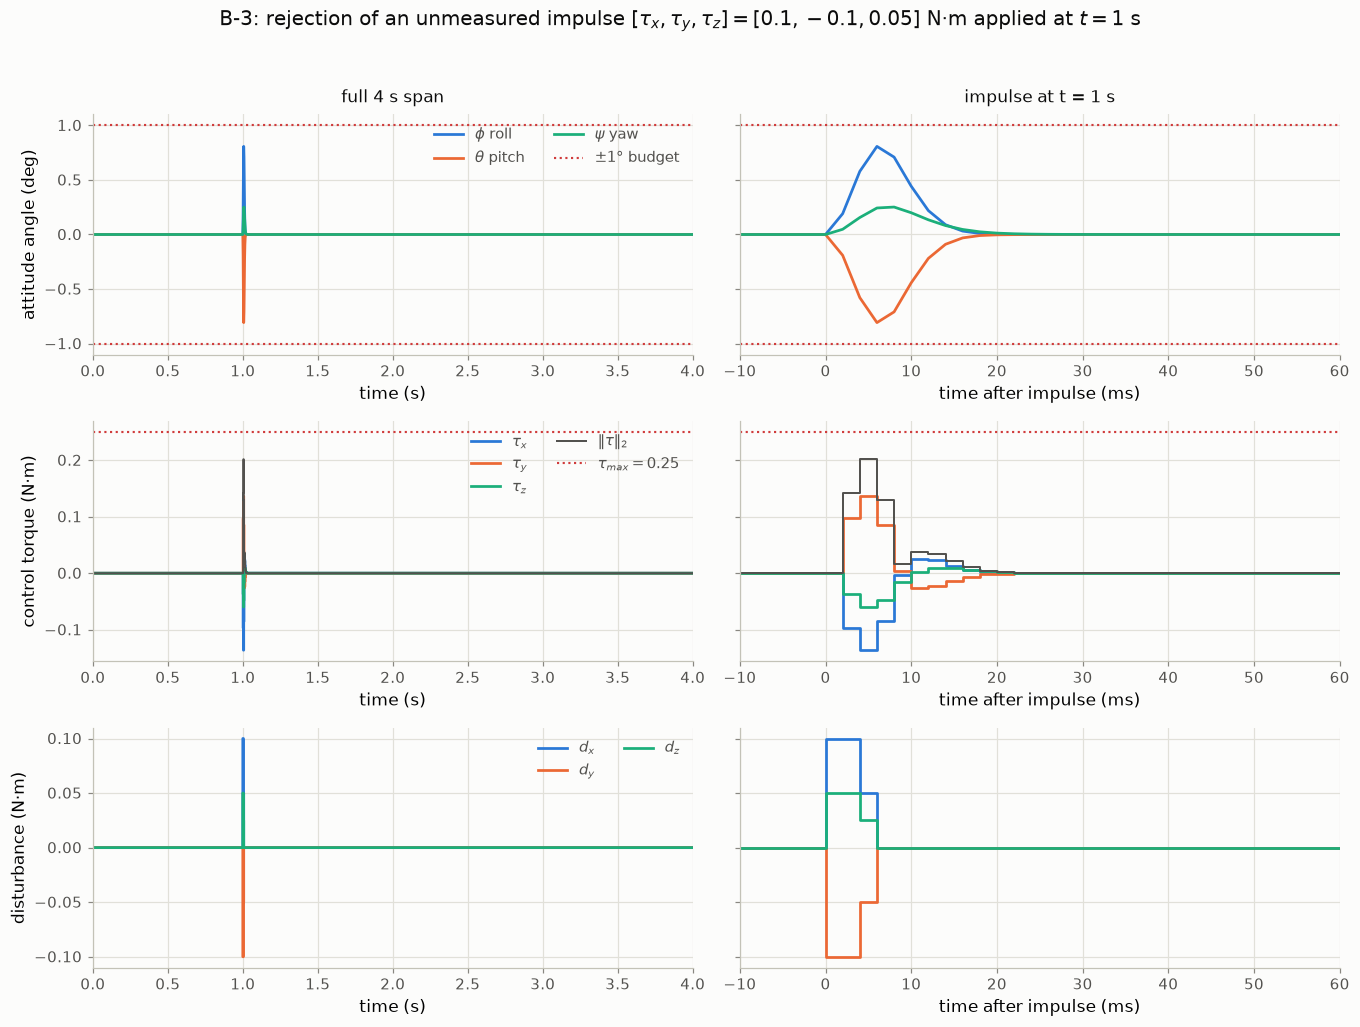

In [12]:
# B-3 figure — the whole event lasts ~40 ms inside a 4 s window, so the full span
# is paired with a zoom on the impulse. Row 3 shows what was actually injected.
VIEWS3 = [("full 4 s span",      0.00, 4.00, 0.0, 1.0, "time (s)"),
          ("impulse at t = 1 s", 0.99, 1.06, 1.0, 1e3, "time after impulse (ms)")]

ROWS3 = [("attitude angle (deg)",       t3,      X3[:, :3] / DEG,
          [r"$\phi$ roll", r"$\theta$ pitch", r"$\psi$ yaw"], "default"),
         ("control torque (N$\\cdot$m)", t3[:-1], U3,
          [r"$\tau_x$", r"$\tau_y$", r"$\tau_z$"], "steps-post"),
         ("disturbance (N$\\cdot$m)",    t3[:-1], D3,
          [r"$d_x$", r"$d_y$", r"$d_z$"], "steps-post")]

fig, axes = plt.subplots(3, 2, figsize=(12.5, 9.5), sharey="row")
for j, (title, lo, hi, shift, scale, xlabel) in enumerate(VIEWS3):
    for i, (ylabel, tb, Y, names, zoh) in enumerate(ROWS3):
        ax = axes[i, j]
        x = (tb - shift) * scale
        for s in range(3):
            ax.plot(x, Y[:, s], color=SERIES[s], label=names[s], drawstyle=zoh)
        if i == 0:                                   # the 1 deg deviation budget
            for sgn in (1, -1):
                ax.axhline(sgn, color=CRIT, ls=":", lw=1.4,
                           label=r"$\pm1°$ budget" if sgn > 0 else None)
        if i == 1:                                   # shared l2 budget and its limit
            ax.plot(x, np.linalg.norm(U3, axis=1), color=INK, lw=1.3,
                    drawstyle="steps-post", label=r"$\|\tau\|_2$")
            ax.axhline(TAU_MAX, color=CRIT, ls=":", lw=1.4, label=r"$\tau_{max}=0.25$")
        ax.set_xlim((lo - shift) * scale, (hi - shift) * scale)
        ax.set_ylabel(ylabel if j == 0 else "")
        ax.set_xlabel(xlabel)
        if i == 0:
            ax.set_title(title, color="#0b0b0b", pad=8)
        if j == 0:
            ax.legend(loc="upper right", ncol=2, labelcolor=INK)

fig.suptitle(r"B-3: rejection of an unmeasured impulse "
             r"$[\tau_x,\tau_y,\tau_z]=[0.1,-0.1,0.05]$ N$\cdot$m applied at $t=1$ s",
             fontsize=13, color="#0b0b0b", y=0.98)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()